In [4]:
# import libraries
from cil.optimisation.functions import L2NormSquared, MixedL21Norm, OperatorCompositionFunction
from cil.optimisation.operators import GradientOperator, IdentityOperator
from cil.optimisation.algorithms import FISTA
from cil.utilities.dataexample import TestData
from cil.utilities.display import plotter2D

import matplotlib.pyplot as plt
import numpy as np

import os, sys

In [5]:
# Load an image from the CIL gallery. 
loader = TestData(data_dir=os.path.join(sys.prefix, 'share','cil'))
data = loader.load(TestData.SHAPES)
ig = data.geometry

In [6]:
# Add gaussian noise
noisy_data = TestData.random_noise(data, mode = 'gaussian', seed = 10, var = 0.005)

In [16]:
# Regularisation parameter for the Total variation term
alpha = 2

G = 0.5 * L2NormSquared(b=noisy_data)
F = OperatorCompositionFunction(alpha * L2NormSquared(), GradientOperator(ig))

fista = FISTA(initial = ig.allocate(), f = F, g=G, 
              max_iteration = 500, update_objective_interval = 100)
fista.run()

Initialised GradientOperator with C backend running with  20  threads
FISTA setting up
FISTA configured
     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        500         0.002          1.03383e+04
      100        500         0.002          3.84968e+02
      200        500         0.002          3.84761e+02
      300        500         0.001          3.84760e+02
      400        500         0.001          3.84760e+02
      500        500         0.001          3.84760e+02
-------------------------------------------------------
      500        500         0.001          3.84760e+02
Stop criterion has been reached.



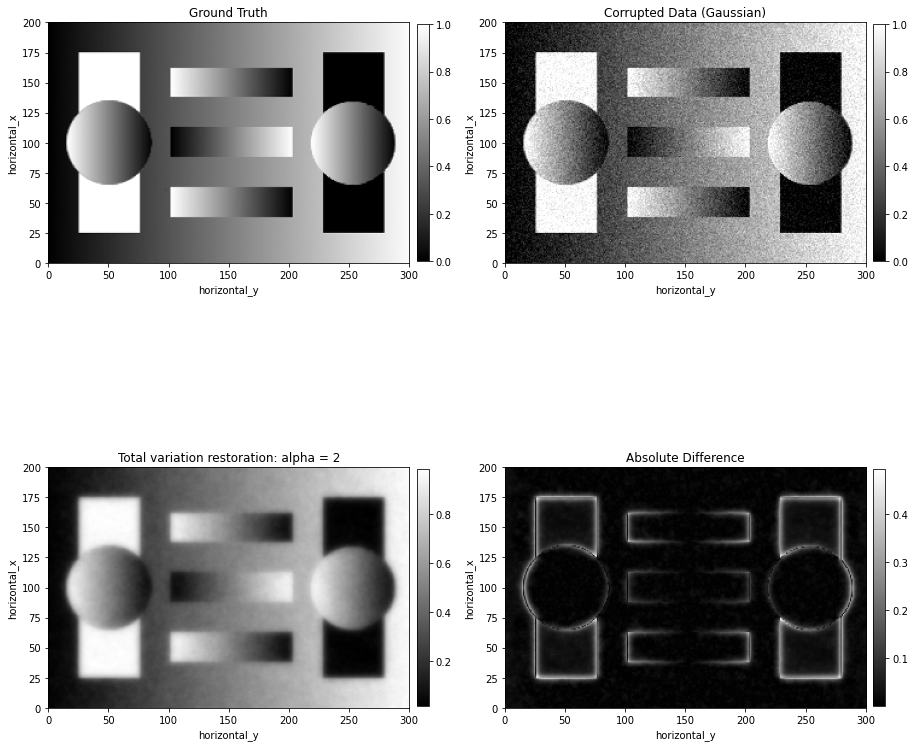

In [17]:
plotter2D([data, noisy_data, fista.solution, (fista.solution-data).abs()],
          titles=["Ground Truth", 
                  "Corrupted Data (Gaussian)", 
                  "Tikhonov restoration: alpha = {}".format(alpha),
                  "Absolute Difference"])